Loading dataset from /content/sample_data/mnist_test.csv...
Data prepared successfully.

Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8777 - loss: 0.4150 - val_accuracy: 0.9555 - val_loss: 0.1404
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9672 - loss: 0.1064 - val_accuracy: 0.9665 - val_loss: 0.1132
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9795 - loss: 0.0623 - val_accuracy: 0.9805 - val_loss: 0.0667
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9841 - loss: 0.0413 - val_accuracy: 0.9775 - val_loss: 0.0785
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9910 - loss: 0.0276 - val_accuracy: 0.9775 - val_loss: 0.0847
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9901 - loss: 0.0260 - val_accuracy: 0.9740 - val_loss: 0.0995
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0.9790 - val_loss: 0.0754
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9950 - loss: 0.0141 - val_ac

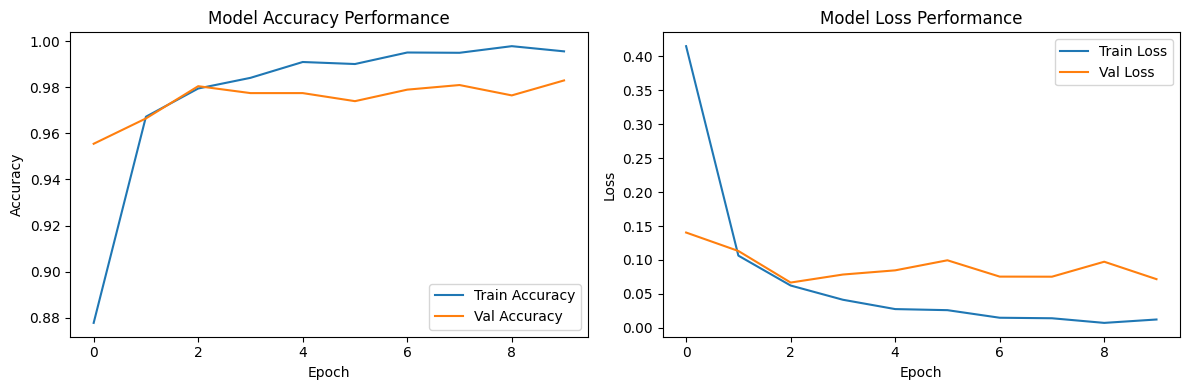

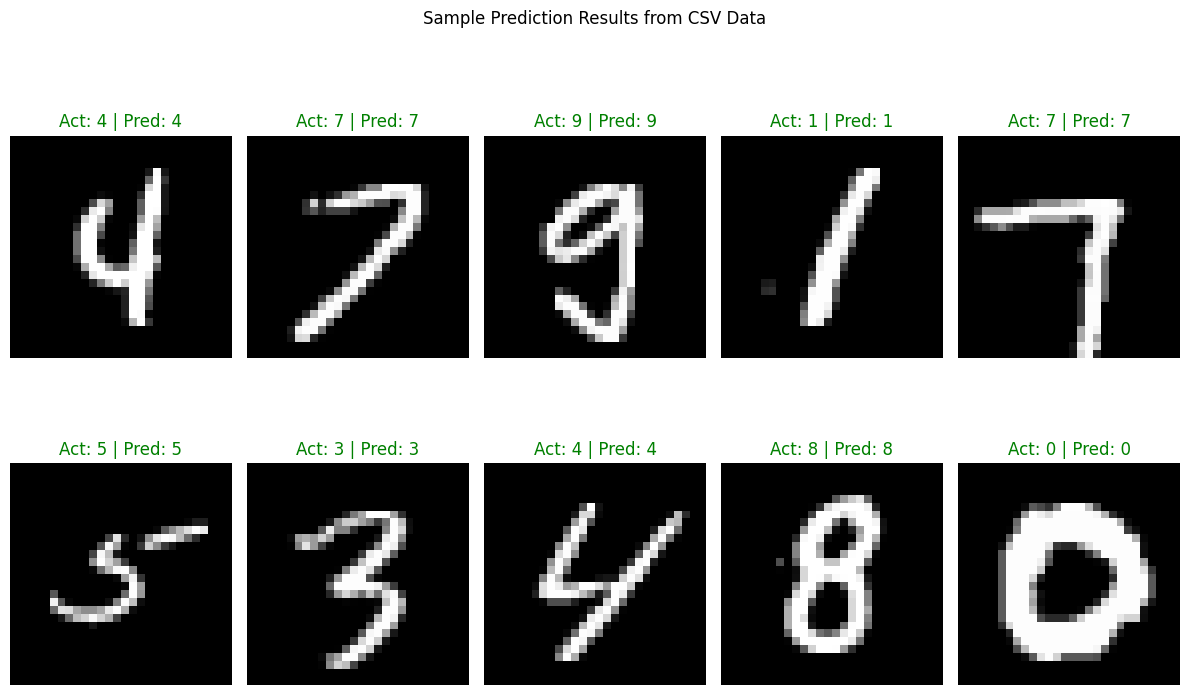

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
def load_data(file_path):
    print(f"Loading dataset from {file_path}...")
    data = pd.read_csv(file_path)

    # Extract labels and pixel data
    y = data.iloc[:, 0].values
    X = data.iloc[:, 1:].values

    # Normalize pixel values (0-255 to 0.0-1.0)
    X = X.astype('float32') / 255.0

    # Reshape for CNN: (Batch, Height, Width, Channels)
    X = X.reshape(-1, 28, 28, 1)

    return X, y

# Load your uploaded file
try:
    # If only test file exists, we split it
    X_test, y_test = load_data('/content/sample_data/mnist_test.csv')

    # In full experiment, replace with:
    # X_train, y_train = load_data('mnist_train.csv')

    X_train, X_val, y_train, y_val = train_test_split(
        X_test, y_test, test_size=0.2, random_state=42
    )

    print("Data prepared successfully.")

except FileNotFoundError:
    print("Error: mnist_test.csv not found. Please ensure the file is in the working directory.")

# ==========================================
# 2. BASELINE CNN DESIGN (No Tuning)
# ==========================================
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes (0–9)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 3. TRAINING
# ==========================================
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    verbose=1
)

# ==========================================
# 4. PERFORMANCE ANALYTICAL METRICS
# ==========================================
print("\n" + "="*30)
print("PERFORMANCE ANALYTICAL METRICS")
print("="*30)

# Evaluate on validation set
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed Classification Report
y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nDetailed Metrics:")
print(classification_report(y_val, y_pred))

# ==========================================
# 5. VISUAL OUTPUTS
# ==========================================

# Visual 1: Training History Graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Visual 2: Actual Prediction Results (Image Grid)
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    img = X_val[i].reshape(28, 28)
    actual_label = y_val[i]
    pred_label = y_pred[i]

    color = 'green' if actual_label == pred_label else 'red'

    plt.imshow(img, cmap='gray')
    plt.title(f"Act: {actual_label} | Pred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle("Sample Prediction Results from CSV Data")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Optimized Training with Hyperparameter Tuning...
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 58s 375ms/step - accuracy: 0.7516 - loss: 0.8048 - val_accuracy: 0.1110 - val_loss: 9.7838 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 52s 366ms/step - accuracy: 0.9243 - loss: 0.2521 - val_accuracy: 0.1110 - val_loss: 7.3974 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 368ms/step - accuracy: 0.9484 - loss: 0.1680 - val_accuracy: 0.4550 - val_loss: 1.6130 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 51s 363ms/step - accuracy: 0.9544 - loss: 0.1484 - val_accuracy: 0.9690 - val_loss: 0.0846 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 53s 377ms/step - accuracy: 0.9624 - loss: 0.1245 - val_accuracy: 0.9920 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 388ms/step - accuracy: 0.9651 - loss: 0.1078 - val_accuracy: 0.9950 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 7/20


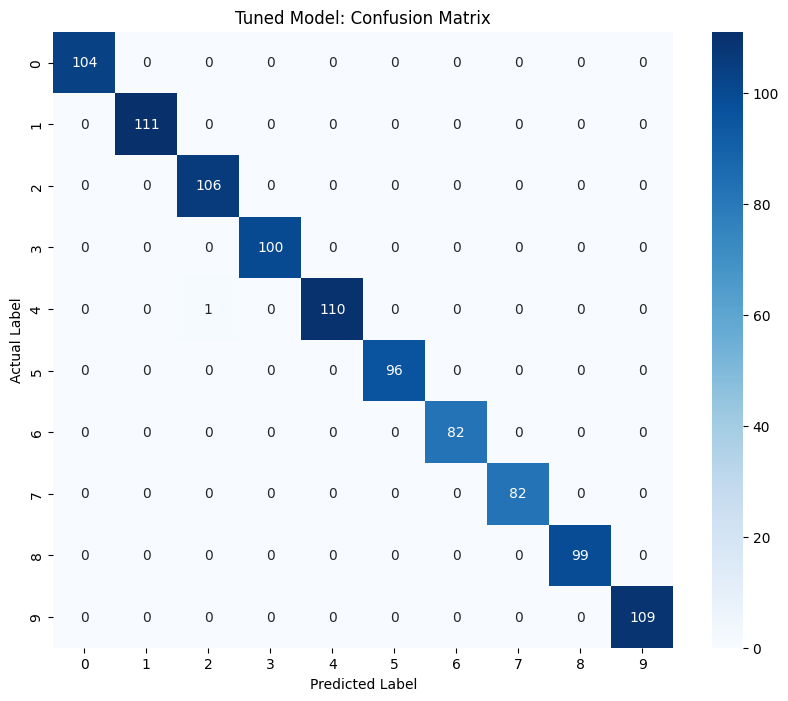

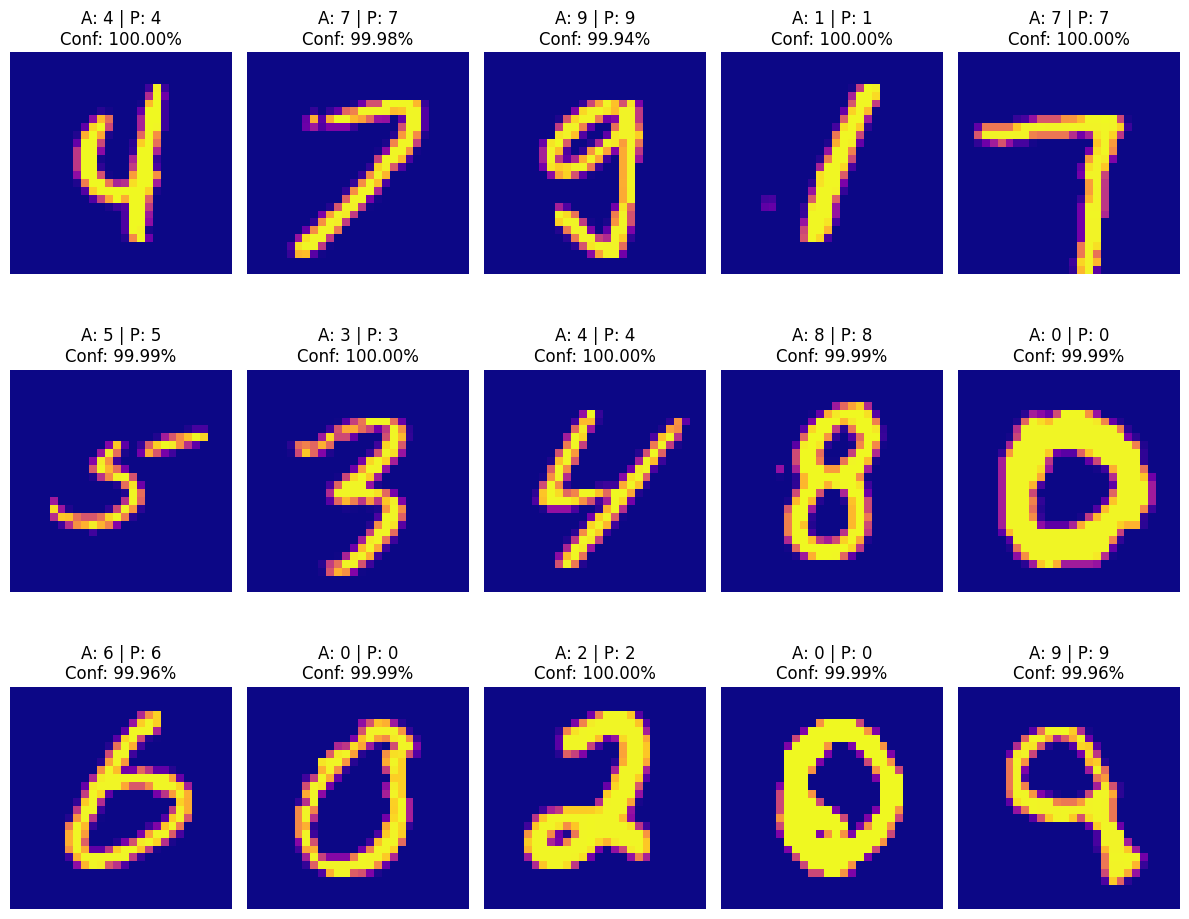

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
# ==========================================
# 1. DATA PREPARATION (Optimized)
# ==========================================
def load_and_preprocess(file_path):
    data = pd.read_csv(file_path)
    y = data.iloc[:, 0].values
    X = data.iloc[:, 1:].values.astype('float32') / 255.0
    X = X.reshape(-1, 28, 28, 1)
    return X, y
X_raw, y_raw = load_and_preprocess('/content/sample_data/mnist_test.csv')
X_train, X_val, y_train, y_val = (
    train_test_split(X_raw, y_raw, test_size=0.1, random_state=42)
)
# DATA AUGMENTATION: This is the key "Tuning" step to increase accuracy
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)
# ==========================================
# 2. TUNED CNN ARCHITECTURE
# ==========================================
model = Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    # Final Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
# Hyperparameter: Learning Rate Scheduler
lr_reduction = (
    ReduceLROnPlateau(monitor='val_accuracy', patience=3, verbose=1, factor=0.5, min_lr=0.00001)
)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# ==========================================
# 3. TRAINING WITH AUGMENTATION
# ==========================================
print("\nStarting Optimized Training with Hyperparameter Tuning...")
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                      epochs=20, # Increased epochs for better convergence
                      validation_data=(X_val, y_val),
                      callbacks=[lr_reduction],
                      verbose=1)
# ==========================================
# 4. TUNED PERFORMANCE ANALYTICAL METRICS
# ==========================================
print("\n" + "="*40)
print("TUNED PERFORMANCE ANALYTICAL METRICS")
print("="*40)
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Final Tuned Accuracy: {accuracy*100:.2f}%")
y_pred = np.argmax(model.predict(X_val), axis=1)
print("\nAdvanced Classification Report:")
print(classification_report(y_val, y_pred))
# ==========================================
# 5. TUNED VISUAL OUTPUTS
# ==========================================
# Visual 1: Confusion Matrix Heatmap (New for Analysis)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Model: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
# Visual 2: Detailed Prediction Grid
plt.figure(figsize=(12, 10))
for i in range(15):
    plt.subplot(3, 5, i+1)
    img = X_val[i].reshape(28, 28)
    actual = y_val[i]
    pred = y_pred[i]
    plt.imshow(img, cmap='plasma') # Changed color map for visual distinction
    plt.title(f"A: {actual} | P: {pred}\nConf: {np.max(model.predict(X_val[i:i+1], verbose=0)):.2%}")
    plt.axis('off')
plt.tight_layout()
plt.show()